In [42]:
import pandas as pd
import matplotlib.pyplot as plt

Get alcohol data in

In [43]:
# get all 2026 iowa alcohol data
data = pd.concat([pd.read_csv("iowa_liquor_sales_2026_1263_rows_part_0001.csv"), 
                  pd.read_csv("iowa_liquor_sales_2026_1263_rows_part_0002.csv"), 
                  pd.read_csv("iowa_liquor_sales_2026_1263_rows_part_0003.csv"), 
                  pd.read_csv("iowa_liquor_sales_2026_1263_rows_part_0004.csv")], ignore_index=True)
data.shape[0]

1952161

In [44]:
data.head()

,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,...,item_no,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_bottles,sales_dollars,sales_liters,sales_gallons
0,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158.0,19127.0,MARSHALL,1022200.0,...,88296,PATRON SILVER,12,750,24.99,37.49,60,2249.40,45.0,11.887740
1,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158.0,19127.0,MARSHALL,1082200.0,...,69947,RUMPLE MINZE PEPPERMINT SCHNAPPS LIQUEUR,12,1000,16.99,25.49,36,917.64,36.0,9.510192
2,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002.0,19001.0,ADAIR,1022200.0,...,87484,DON JULIO BLANCO,12,375,14.00,22.00,3,67.00,1.0,0.000000
3,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002.0,19001.0,ADAIR,1022200.0,...,88296,PATRON SILVER,12,750,24.00,37.00,12,449.00,9.0,2.000000
4,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002.0,19001.0,ADAIR,1081300.0,...,84393,99 WATERMELON PET MINI,1,50,54.00,81.00,1,81.00,0.0,0.000000


Get Iowa university location data

In [ ]:
# get a list of all universities in Iowa
# taken from: https://en.wikipedia.org/wiki/List_of_colleges_and_universities_in_Iowa
universities = pd.read_csv("iowa_universities.csv")
universities.head()

,Institution,Location,Control,Type,Enrollment,Founded,Accreditation
0,University of Iowa,Iowa City,Public,Research university,"30,779",1847,"HLC, ACPE, ABA, ADA, APTA, APA, ASHA, CPE, CAH..."
1,Iowa State University,Ames,Public,Research university,"30,380",1858[8],"HLC, AAMFT, ADA, APA, AVMA, NASM"
2,University of Northern Iowa,Cedar Falls,Public,Master's university,"9,278",1876[9],"HLC, ASHA, NASM"
3,Des Moines Area Community College,Ankeny,Public,Associate's college,"23,697",1966[10],"HLC, ABFSE, ADA, NLNAC"
4,Eastern Iowa Community Colleges,Davenport,Public,Associate's college,"7,426",1965[11],HLC


In [46]:
# list of cities with universities
cities = universities['Location'].str.lower().unique()
cities

array(['iowa city', 'ames', 'cedar falls', 'ankeny', 'davenport',
       'iowa falls', 'waterloo', 'ottumwa', 'fort dodge', 'estherville',
       'council bluffs', 'cedar rapids', 'marshalltown', 'mason city',
       'calmar', 'sheldon', 'west burlington', 'creston', 'sioux city',
       'storm lake', 'pella', 'dubuque', 'mount vernon', 'des moines',
       'epworth', 'sioux center', 'lamoni', 'grinnell', 'decorah',
       'fairfield', 'orange city', 'indianola', 'fayette', 'waverly',
       'oskaloosa', 'forest city'], dtype=object)

Join alcohol and university data

In [47]:
# dummy variable for if store_city has a university in it
data['university'] = data['store_city'].str.lower().isin(cities)

In [48]:
# convert str to dates
data['ordered_on'] = pd.to_datetime(data['ordered_on'])

In [49]:
university_data = data[data['university'] == True]
university_data.head(1)

,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,...,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_bottles,sales_dollars,sales_liters,sales_gallons,university
0,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158.0,19127.0,MARSHALL,1022200.0,...,PATRON SILVER,12,750,24.99,37.49,60,2249.4,45.0,11.88774,True


In [50]:
no_university_data = data[data['university'] == False]
no_university_data.head(1)

,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,...,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_bottles,sales_dollars,sales_liters,sales_gallons,university
2,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002.0,19001.0,ADAIR,1022200.0,...,DON JULIO BLANCO,12,375,14.0,22.0,3,67.0,1.0,0.0,False


Compare alcohol sales between the city types

In [67]:
# for now, calculate total gallons ordered by city type (university vs. no university)
university_gallons_sum = university_data['sales_gallons'].sum()
no_university_gallons_sum = no_university_data['sales_gallons'].sum()

# ~25% more gallons of alcohol sold in university cities?
university_gallons_sum / no_university_gallons_sum

np.float64(1.253238082938328)

In [ ]:
# now compare means
university_gallons_avg = university_data['sales_gallons'].mean()
no_university_gallons_avg = no_university_data['sales_gallons'].mean()

# about the same ratio as the sum
university_gallons_avg / no_university_gallons_avg

np.float64(2.4870824427505878)

Text(0.5, 1.0, 'Alcohol Ordered (University Cities)')

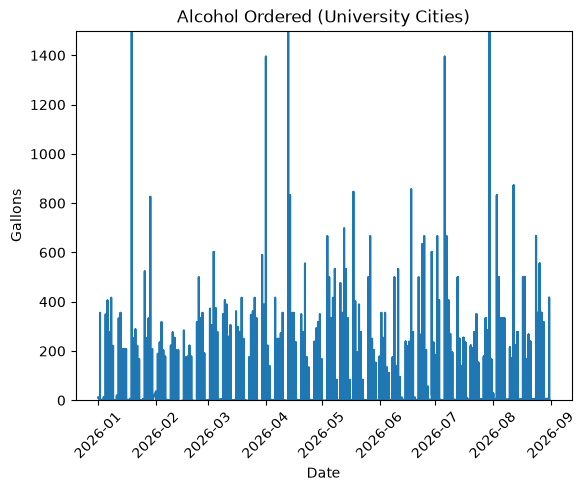

In [70]:
# university
plt.plot(university_data['ordered_on'], university_data['sales_gallons'])
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Gallons')
plt.ylim((0, 1500))
plt.title('Alcohol Ordered (University Cities)')

Text(0.5, 1.0, 'Alcohol Ordered (Non-University Cities)')

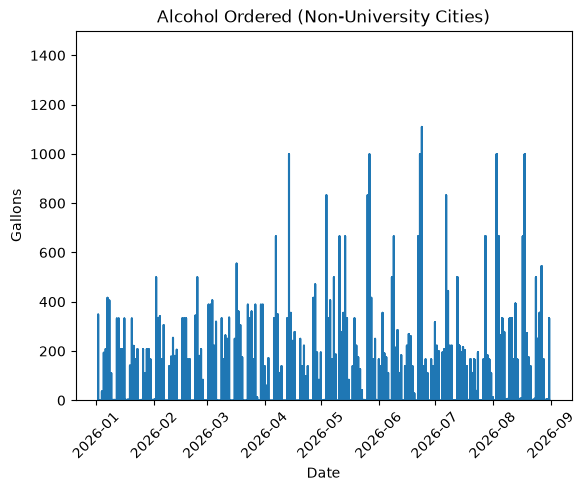

In [71]:
# non university
plt.plot(no_university_data['ordered_on'], no_university_data['sales_gallons'])
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Gallons')
plt.ylim((0, 1500))
plt.title('Alcohol Ordered (Non-University Cities)')